# Isolated test for Quantum Builders (Square Grid)
This section builds a 2D pure grid manually (without `System` or `poisson` generation). Then it immediately invokes either `kwant_solver` or `default_solver`.

In [1]:
import os
import sys
sys.path.append(os.getcwd()+"/Equantum")
import numpy as np
import matplotlib.pyplot as plt
import importlib
%matplotlib inline

from quantum_solvers.default_solver import QuantumSystem
from quantum_solvers import kwant_solver


## 1. Mocking the System Class
We need to mock out the bare minimum that `QuantumSystem` and `kwant_builder` look for to function on a direct 2D list of Sites.

In [2]:
class MockSite:
    def __init__(self, idx, coords):
        self.id = idx
        self.coordinates = coords
        self.pos = coords  # kwant specifically uses .pos sometimes
        self.neighbors = {} # map of neighbor_idx -> direction/distance obj
        self.material = 'Qsystem'

class MockSystem:
    def __init__(self, L=10, W=10, a=1.0):
        self.L = L
        self.W = W
        self.lat_spacing = a
        self.t = 1.0
        self.geometry_params = {'lattice_type': 'square', 'sampling_density_function': lambda z: a}
        
        self.sites = {}  # Keep the full dict
        self.Qsites = [] # List of IDs
        
        self._build_grid()
        
    def _build_grid(self):
        grid = np.zeros((self.L, self.W), dtype=int)
        # Create Sites
        count = 0
        for x in range(self.L):
            for y in range(self.W):
                coords = [x * self.lat_spacing, y * self.lat_spacing, 0.0]
                site = MockSite(count, coords)
                self.sites[count] = site
                self.Qsites.append(count)
                grid[x, y] = count
                count += 1
                
        # Assign Neighbors (Square Grid)
        for x in range(self.L):
            for y in range(self.W):
                idx = grid[x, y]
                nhbrs = []
                if x > 0: nhbrs.append(grid[x-1, y])
                if x < self.L - 1: nhbrs.append(grid[x+1, y])
                if y > 0: nhbrs.append(grid[x, y-1])
                if y < self.W - 1: nhbrs.append(grid[x, y+1])
                
                # Fill neighbor dictionary with dummy distances
                for n in nhbrs:
                    self.sites[idx].neighbors[n] = self.lat_spacing


## 2. Test Default Solver
Ensure `default_solver` functions seamlessly on the isolated mesh.

In [14]:
print("Generating MOCK System (20x20) grid...")
mock_syst = MockSystem(L=50, W=50)
qparams = {'Ufunc': lambda site: 0.0, 'phi': 0.05}

print("Testing Default Solver Construction...")
def_solver = QuantumSystem(mock_syst, params=qparams)

print(f"Hamiltonian built successfully. Shape: {def_solver.H.shape}")

# Compute DOS for center site
center_idx = mock_syst.L * mock_syst.W // 2 + mock_syst.W // 2
print(f"Computing DOS at central site ID: {center_idx} ...")
energies_def, dos_def = def_solver.get_dos(params=qparams, i=[center_idx])
print("Done.")


Generating MOCK System (20x20) grid...
Testing Default Solver Construction...
Hamiltonian built successfully. Shape: (2500, 2500)
Computing DOS at central site ID: 1275 ...
Done.


## 3. Test Kwant Solver
Check `kwant_solver.kwant_builder()` on the identical object.

In [15]:
print("Testing Kwant Solver Construction...")
kw_syst = kwant_solver.kwant_builder(mock_syst)

def Ufunc(site): return 0.0
# Setting system params as parsed by Kwant
kw_params = {'Ufunc': Ufunc, 'phi': qparams['phi']}

print("Evaluating via Kwant KPM Model...")
import kwant
spectrum_kpm = kwant.kpm.SpectralDensity(kw_syst, params=kw_params, energy_resolution=0.02)
energies_kw, dos_kw = spectrum_kpm()
print("Done.")


Testing Kwant Solver Construction...


100%|██████████| 2500/2500 [00:04<00:00, 615.18it/s]


Evaluating via Kwant KPM Model...
Done.


## 4. Compare Spectrum by Exact Diagonalization
Extract the complete Hamiltonian matrices and diagonalize them to ensure the spectrum matches exactly.

Diagonalizing Default Hamiltonian...
Diagonalizing Kwant Hamiltonian...


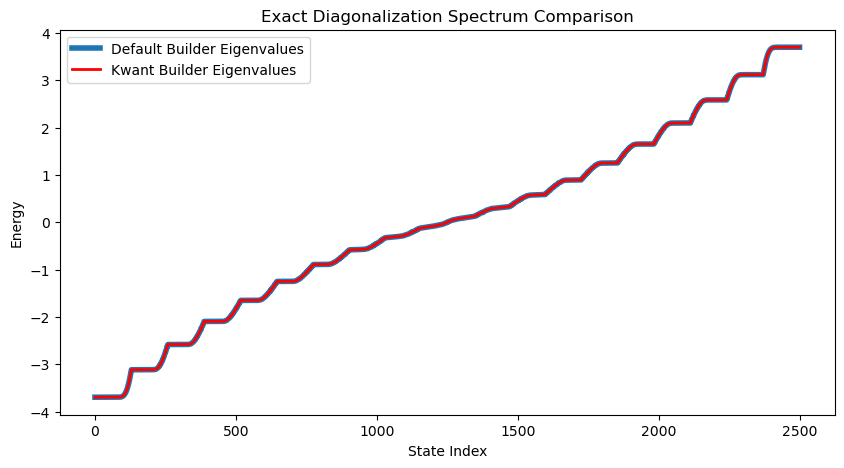

In [16]:
import scipy.linalg as sl
print("Diagonalizing Default Hamiltonian...")
H_def = def_solver.H.toarray()
eig_def = sl.eigh(H_def, eigvals_only=True)

print("Diagonalizing Kwant Hamiltonian...")
H_kw = kw_syst.hamiltonian_submatrix(params=kw_params)
eig_kw = sl.eigh(H_kw, eigvals_only=True)

plt.figure(figsize=(10, 5))
plt.plot(eig_def, label='Default Builder Eigenvalues', lw=4)
plt.plot(np.sort(eig_kw), label='Kwant Builder Eigenvalues', ls='-', c='r', lw=2)
plt.xlabel('State Index')
plt.ylabel('Energy')
plt.title('Exact Diagonalization Spectrum Comparison')
plt.legend()
plt.show()

## 5. Visual Cross-Plot (DOS)

/scratch/zhaoyuha/miniconda3/lib/python3.9/site-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


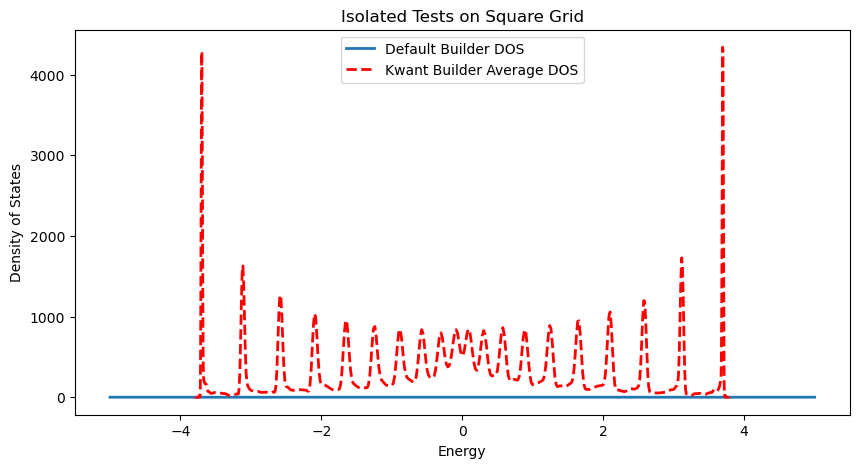

In [17]:
plt.figure(figsize=(10, 5))

plt.plot(energies_def, dos_def, label='Default Builder DOS', lw=2)
plt.plot(energies_kw, dos_kw, label='Kwant Builder Average DOS', ls='--', c='r', lw=2)

plt.xlabel('Energy')
plt.ylabel('Density of States')
plt.title('Isolated Tests on Square Grid')
plt.legend()
plt.show()